In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [3]:
train = pd.read_csv('/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv')
test = pd.read_csv('/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv')


print(train.shape,test.shape)
train.head()

(1296675, 23) (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
def feature_engineering(df):

    df = df.copy()

    # Convert datetime
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
    df["dob"] = pd.to_datetime(df["dob"])

    # Time features
    df["hour"] = df["trans_date_trans_time"].dt.hour
    df["day"] = df["trans_date_trans_time"].dt.day
    df["month"] = df["trans_date_trans_time"].dt.month
    df["weekday"] = df["trans_date_trans_time"].dt.weekday

    # Age
    df["age"] = df["trans_date_trans_time"].dt.year - df["dob"].dt.year

    # Distance
    df["distance"] = np.sqrt(
        (df["lat"] - df["merch_lat"])**2 +
        (df["long"] - df["merch_long"])**2
    )

    # Log amount
    df["amt_log"] = np.log1p(df["amt"])

    # Night transaction
    df["is_night"] = df["hour"].apply(lambda x: 1 if x >= 22 or x <= 4 else 0)

    # Weekend transaction
    df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)

    # Drop unnecessary columns
    drop_cols = [
        "Unnamed: 0",
        "first",
        "last",
        "street",
        "trans_num",
        "cc_num",
        "trans_date_trans_time",
        "dob"
    ]

    df = df.drop(columns=drop_cols)

    return df

In [5]:
test=feature_engineering(test)
train=feature_engineering(train)
print(train.shape)
print(test.shape)
test.head(3)

(1296675, 24)
(555719, 24)


,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,...,is_fraud,hour,day,month,weekday,age,distance,amt_log,is_night,is_weekend
0,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,...,0,12,21,6,6,52,0.266004,1.350667,0,1
1,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,...,0,12,21,6,6,30,0.991674,3.428813,0,1
2,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,40.6729,-73.5365,34496,...,0,12,21,6,6,50,0.682970,3.744314,0,1


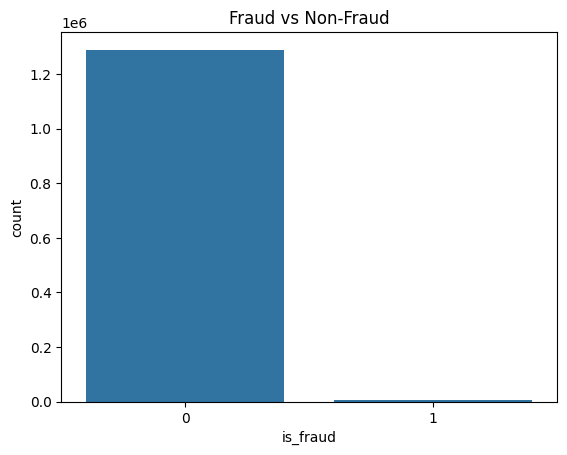

In [17]:
sns.countplot(x="is_fraud", data=train)
plt.title("Fraud vs Non-Fraud")
plt.show()

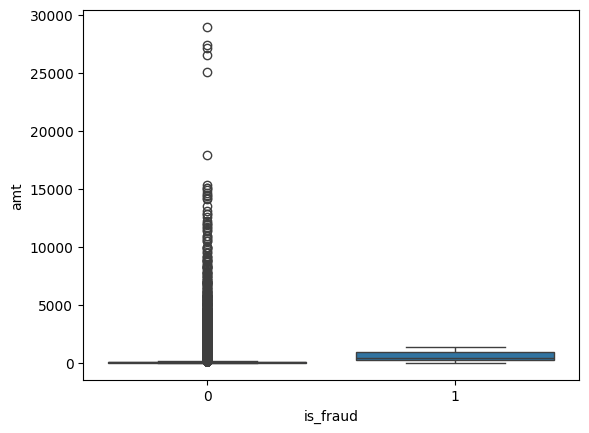

In [29]:
sns.boxplot(x="is_fraud", y="amt", data=train)
plt.show()

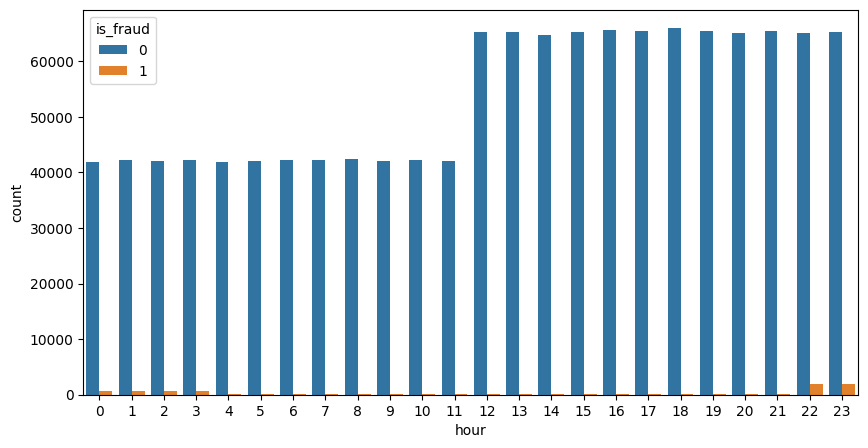

In [30]:
plt.figure(figsize=(10,5))
sns.countplot(x="hour", hue="is_fraud", data=train)
plt.show()

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   merchant    1296675 non-null  object 
 1   category    1296675 non-null  object 
 2   amt         1296675 non-null  float64
 3   gender      1296675 non-null  object 
 4   city        1296675 non-null  object 
 5   state       1296675 non-null  object 
 6   zip         1296675 non-null  int64  
 7   lat         1296675 non-null  float64
 8   long        1296675 non-null  float64
 9   city_pop    1296675 non-null  int64  
 10  job         1296675 non-null  object 
 11  unix_time   1296675 non-null  int64  
 12  merch_lat   1296675 non-null  float64
 13  merch_long  1296675 non-null  float64
 14  is_fraud    1296675 non-null  int64  
 15  hour        1296675 non-null  int32  
 16  day         1296675 non-null  int32  
 17  month       1296675 non-null  int32  
 18  weekday     1296675 no

In [7]:
cat_features=train.select_dtypes(exclude='number').columns.tolist()
print(cat_features)

['merchant', 'category', 'gender', 'city', 'state', 'job']


In [8]:
for col in cat_features:
    train[col]=train[col].astype("category")
    test[col]=test[col].astype("category")


In [9]:
y=train['is_fraud']
y_test=test['is_fraud']

x=train.drop('is_fraud',axis=1)
x_test=test.drop('is_fraud',axis=1)

In [10]:
from sklearn.model_selection import GridSearchCV

In [11]:
model = CatBoostClassifier(
    loss_function="Logloss",
    verbose=False,
    task_type= 'GPU',
    devices= '0:1',
)

In [14]:
param_grid = {
    "learning_rate": [0.005, 0.05, 0.1],
    "iterations": [2000,4000, 3000],
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring="neg_log_loss",
    n_jobs=1
)


In [15]:
grid.fit(x, y,cat_features=cat_features)

GridSearchCV(cv=3,
             estimator=<catboost.core.CatBoostClassifier object at 0x7d9db38d0f20>,
             n_jobs=1,
             param_grid={'iterations': [2000, 4000, 3000],
                         'learning_rate': [0.005, 0.05, 0.1]},
             scoring='neg_log_loss')

In [18]:
 best_params=grid.best_params_

print("Best Params:",best_params)
print("Best Score:", grid.best_score_)

# Best Params: {'iterations': 2000, 'learning_rate': 0.005}
# Best Score: -0.025198227006262355

Best Params: {'iterations': 2000, 'learning_rate': 0.005}
Best Score: -0.025198227006262355


In [19]:
best_model = CatBoostClassifier(
    iterations= 2000,
    learning_rate= 0.005,
    loss_function="Logloss",
    task_type="GPU",
    devices="0:1",
    verbose=False
)

In [22]:
best_model.fit(x, y,cat_features=cat_features)

In [23]:
pred=best_model.predict(x_test)


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.94      0.67      0.78      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.84      0.89    555719
weighted avg       1.00      1.00      1.00    555719



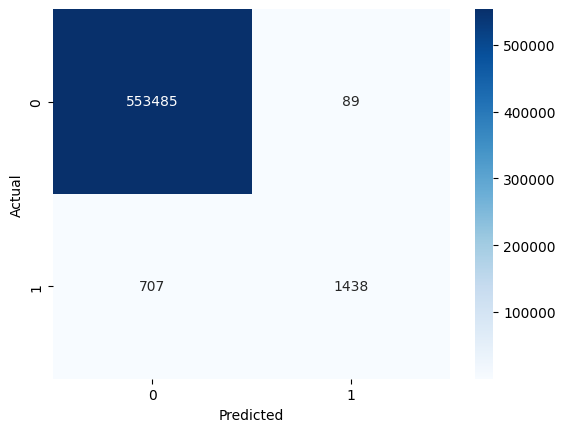

In [24]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
y_test

0         0
1         0
2         0
3         0
4         0
         ..
555714    0
555715    0
555716    0
555717    0
555718    0
Name: is_fraud, Length: 555719, dtype: int64

In [28]:
proba=best_model.predict_proba(x_test)[:,1]

roc = roc_auc_score(y_test, proba)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.991859254778756


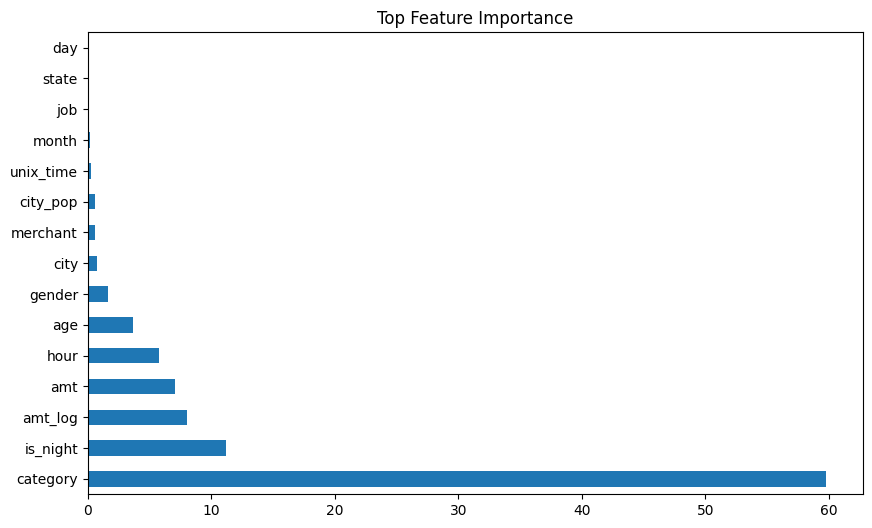

In [33]:
importance = best_model.feature_importances_

feat_imp = pd.Series(importance, index=x.columns).sort_values(ascending=False)

feat_imp.head(15).plot(kind="barh", figsize=(10,6))
plt.title("Top Feature Importance")
plt.show()

In [34]:
best_model.save_model('credit_fraud_detection.cmb')